# NALAPRO — Task 1: Text Classification on 20 Newsgroups
### With Weights & Biases (W&B) Experiment Tracking

**Student:** [Your Name]  
**Dataset:** `sklearn.datasets.fetch_20newsgroups`  
**Goal:** Classify news articles into 20 categories using a feedforward neural network with different input representations.

---

## What this notebook covers:
- **Task 1a** — Preprocessing: cleaning, tokenizing, removing stopwords
- **Task 1b** — Word2Vec embeddings → Neural Network (1 epoch vs 15 epochs comparison)
- **Task 1c** — TF-IDF vectorization → Neural Network (comparison with Word2Vec)
- **Task 1d** — Custom experiment: Concatenated Word2Vec + TF-IDF features

## Tools used:
- `PyTorch` — neural network implementation
- `Gensim` — Word2Vec training
- `scikit-learn` — TF-IDF, dataset loading, metrics
- `NLTK` — stopwords, tokenization
- `Weights & Biases (wandb)` — experiment tracking, metric graphs, artifact logging
- `matplotlib / seaborn` — local visualization
- AI Assistance: Claude (Anthropic) — used for code structure. All code understood and verified by author.

## W&B Project Link:
> **[TODO: paste your W&B project URL here after first run]**  
> e.g. `https://wandb.ai/your-username/nalapro-task1`

---
## Cell 1 — Install & Import All Libraries

We install `wandb` alongside all other required packages.  
Run this cell once, then restart the kernel if prompted.

In [1]:
# ── Install all dependencies (run once) ─────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'gensim', 'nltk', 'torch', 'scikit-learn',
                'matplotlib', 'seaborn', 'numpy', 'pandas', 'wandb'],
               capture_output=True)

# ── Standard library ─────────────────────────────────────────────────
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ── Numerical ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── NLP ──────────────────────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from gensim.models import Word2Vec

# ── Machine Learning ─────────────────────────────────────────────────
from sklearn.datasets                import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition           import TruncatedSVD
from sklearn.pipeline                import Pipeline
from sklearn.metrics                 import (accuracy_score,
                                              classification_report,
                                              confusion_matrix)

# ── PyTorch ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Visualization ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.manifold   import TSNE
from sklearn.decomposition import PCA

# ── Weights & Biases ──────────────────────────────────────────────────
import wandb
# wandb.login() is called separately in Cell 2 below

# ── Global settings ───────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs('outputs', exist_ok=True)

# ── W&B project config ────────────────────────────────────────────────
# All runs go under this project name on your W&B dashboard
WANDB_PROJECT = 'nalapro-task1'

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'W&B     : {wandb.__version__}')
print('All libraries loaded!')

Device  : cpu
PyTorch : 2.10.0+cpu
W&B     : 0.26.1
All libraries loaded!


---
## Cell 2 — Login to Weights & Biases

Run this once to authenticate. You'll be asked to paste an API key.

**Steps:**
1. Go to [https://wandb.ai](https://wandb.ai) and create a free account
2. Go to **Settings → API Keys** and copy your key
3. Run this cell and paste the key when prompted

> After first login, W&B saves your credentials locally — you won't need to log in again on this machine.

In [2]:
# ── Authenticate with W&B ────────────────────────────────────────────
# This opens a prompt asking for your API key.
# Get it from: https://wandb.ai/authorize
wandb.login()

print(f'Logged in. Runs will appear at: https://wandb.ai/<your-username>/{WANDB_PROJECT}')

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: likhita-kolli (likhita-kolli-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged in. Runs will appear at: https://wandb.ai/<your-username>/nalapro-task1


---
## Cell 3 — Load the Dataset

We remove headers/footers/quotes to prevent **data leakage** —  
email headers contain the newsgroup name which would let the model cheat.

In [3]:
train_data = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=RANDOM_SEED
)
test_data = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=RANDOM_SEED
)

CLASS_NAMES = train_data.target_names
NUM_CLASSES  = len(CLASS_NAMES)

print(f'Train docs : {len(train_data.data)}')
print(f'Test  docs : {len(test_data.data)}')
print(f'Classes    : {NUM_CLASSES}')
print(f'\nCategories:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i:2d}. {name}')

Train docs : 11314
Test  docs : 7532
Classes    : 20

Categories:
   0. alt.atheism
   1. comp.graphics
   2. comp.os.ms-windows.misc
   3. comp.sys.ibm.pc.hardware
   4. comp.sys.mac.hardware
   5. comp.windows.x
   6. misc.forsale
   7. rec.autos
   8. rec.motorcycles
   9. rec.sport.baseball
  10. rec.sport.hockey
  11. sci.crypt
  12. sci.electronics
  13. sci.med
  14. sci.space
  15. soc.religion.christian
  16. talk.politics.guns
  17. talk.politics.mideast
  18. talk.politics.misc
  19. talk.religion.misc


---
## Cell 4 — Text Preprocessing (Task 1a)

Clean raw text: remove headers, URLs, emails, punctuation, stopwords, short tokens.  
Output two formats: **token lists** (for Word2Vec) and **joined strings** (for TF-IDF).

In [4]:
STOP_WORDS = set(stopwords.words('english'))


def clean_text(text: str) -> str:
    """Remove noise: headers, URLs, emails, punctuation, digits. Lowercase."""
    text = re.sub(r'^[\w\-]+:.*$',    '', text, flags=re.MULTILINE)  # headers
    text = re.sub(r'http\S+|www\.\S+', '', text)                      # URLs
    text = re.sub(r'\S+@\S+',          '', text)                      # emails
    text = re.sub(r'[^a-zA-Z\s]',      '', text)                      # non-alpha
    text = re.sub(r'\s+',              ' ', text).strip().lower()      # whitespace
    return text


def tokenize(text: str) -> list:
    """Split into tokens; remove stopwords and short tokens (<3 chars)."""
    tokens = text.split()
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 2]


def preprocess_corpus(texts: list, return_tokens: bool = True) -> list:
    """
    Preprocess an entire corpus.
    return_tokens=True  → List[List[str]]  (needed by Word2Vec)
    return_tokens=False → List[str]         (needed by TF-IDF)
    """
    result = []
    for text in texts:
        tokens = tokenize(clean_text(text))
        result.append(tokens if return_tokens else ' '.join(tokens))
    return result


# Run preprocessing — both formats needed
print('Preprocessing training data...')
train_tokens  = preprocess_corpus(train_data.data, return_tokens=True)
train_strings = preprocess_corpus(train_data.data, return_tokens=False)

print('Preprocessing test data...')
test_tokens   = preprocess_corpus(test_data.data,  return_tokens=True)
test_strings  = preprocess_corpus(test_data.data,  return_tokens=False)

y_train = train_data.target
y_test  = test_data.target

print(f'\nBEFORE: {train_data.data[0][:150]}')
print(f'\nAFTER : {train_tokens[0][:15]}')

Preprocessing training data...
Preprocessing test data...

BEFORE: I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
ea

AFTER : ['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sports', 'car', 'looked', 'late', 'early', 'called', 'bricklin']


---
## Cell 5 — Neural Network Architecture

Fixed for ALL experiments:
```
Input → Linear(input_dim → 256) → ReLU → Dropout(0.3) → Linear(256 → 20)
```
Architecture is constant so differences in results are due to the input representation only.

In [5]:
class FeedforwardNN(nn.Module):
    """
    Two-layer feedforward neural network with ReLU activation.
    Architecture: Linear → ReLU → Dropout → Linear
    """

    def __init__(self, input_dim: int, hidden_dim: int = 256,
                 num_classes: int = 20, dropout_p: float = 0.3):
        super(FeedforwardNN, self).__init__()
        self.layer1  = nn.Linear(input_dim, hidden_dim)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)
        self.layer2  = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer1(x)   # (batch, input_dim) → (batch, 256)
        x = self.relu(x)     # max(0, x)
        x = self.dropout(x)  # zero 30% during training
        x = self.layer2(x)   # (batch, 256) → (batch, 20)
        return x             # raw logits — CrossEntropyLoss handles softmax


def build_dataloaders(X_train, y_train, X_test, y_test,
                      batch_size=64, val_split=0.1):
    """Build train / val / test DataLoaders from numpy arrays."""
    n_val = int(len(X_train) * val_split)
    X_val, y_val = X_train[:n_val], y_train[:n_val]
    X_tr,  y_tr  = X_train[n_val:], y_train[n_val:]

    def make_loader(X, y, shuffle):
        ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                           torch.tensor(y, dtype=torch.long))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    return (make_loader(X_tr,   y_tr,   shuffle=True),
            make_loader(X_val,  y_val,  shuffle=False),
            make_loader(X_test, y_test, shuffle=False))


print('Neural network defined!')

Neural network defined!


---
## Cell 6 — Training Loop WITH Weights & Biases Logging

This is where W&B is integrated. Every experiment automatically logs:
- **Config** — all hyperparameters
- **Per-epoch metrics** — train/val loss and accuracy as live charts
- **Test accuracy** — final result
- **Confusion matrix** — as a W&B Table and image
- **Plots** — training curves, embedding comparisons uploaded as artifacts
- **Model** — saved weights uploaded as a W&B artifact

In [6]:
def train_and_evaluate_wandb(
        model,
        train_loader,
        val_loader,
        test_loader,
        config: dict,
        run_name: str,
        tags: list = None
):
    """
    Full training loop with comprehensive W&B logging.

    Logs to W&B:
      - config (hyperparameters)
      - per-epoch: train_loss, train_acc, val_loss, val_acc
      - final: test_accuracy
      - confusion matrix as W&B Table
      - model weights as W&B Artifact

    Args:
        model      : FeedforwardNN instance
        *_loader   : PyTorch DataLoaders
        config     : dict of hyperparameters (logged to W&B)
        run_name   : name shown in W&B dashboard
        tags       : optional list of tag strings for filtering runs

    Returns:
        history      : dict with per-epoch metrics
        eval_results : dict with test accuracy, preds, labels
    """
    # ── Initialise a W&B run ─────────────────────────────────────────
    # Each call creates ONE run on the dashboard with its own page
    run = wandb.init(
        project=WANDB_PROJECT,    # groups all Task 1 runs together
        name=run_name,            # label shown in the runs table
        config=config,            # logs all hyperparameters as config
        tags=tags or [],          # optional labels for filtering
        reinit=True               # allows multiple runs per notebook session
    )

    # Retrieve the logged config (W&B may override with sweep values)
    cfg = wandb.config

    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg.learning_rate)

    # Tell W&B to watch the model: logs gradients and weights histograms
    # log_freq=10 means every 10 batches
    wandb.watch(model, criterion, log='all', log_freq=10)

    history      = {'train_loss': [], 'val_loss': [],
                    'train_acc':  [], 'val_acc':  []}
    best_val_acc = 0.0

    for epoch in range(1, cfg.nn_epochs + 1):

        # ── Training phase ───────────────────────────────────────────
        model.train()
        train_loss, train_preds, train_labels = 0.0, [], []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(y_batch)
            train_preds.extend(logits.argmax(1).cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())

        # ── Validation phase ─────────────────────────────────────────
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits   = model(X_batch)
                loss     = criterion(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_preds.extend(logits.argmax(1).cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())

        # ── Compute metrics ──────────────────────────────────────────
        t_loss = train_loss / len(train_loader.dataset)
        v_loss = val_loss   / len(val_loader.dataset)
        t_acc  = accuracy_score(train_labels, train_preds)
        v_acc  = accuracy_score(val_labels,   val_preds)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc

        # ── Log per-epoch metrics to W&B ─────────────────────────────
        # These appear as live-updating line charts on the W&B run page
        wandb.log({
            'epoch':       epoch,
            'train/loss':  t_loss,   # 'train/' prefix groups in W&B UI
            'train/acc':   t_acc,
            'val/loss':    v_loss,
            'val/acc':     v_acc,
        })

        print(f'Epoch [{epoch:02d}/{cfg.nn_epochs}] | '
              f'Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}')

    # ── Final test evaluation ─────────────────────────────────────────
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.numpy())

    test_acc = accuracy_score(all_labels, all_preds)
    print(f'\n>>> Test Accuracy: {test_acc:.4f}')
    print(classification_report(all_labels, all_preds,
                                target_names=CLASS_NAMES, digits=4))

    # ── Log summary metrics to W&B ───────────────────────────────────
    # wandb.summary values appear in the runs comparison table
    wandb.summary['test_accuracy']   = test_acc
    wandb.summary['best_val_acc']    = best_val_acc

    # ── Log confusion matrix as W&B Table ───────────────────────────
    # Creates an interactive table in W&B — hover to see values
    cm_raw  = confusion_matrix(all_labels, all_preds)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    # Build W&B Table: rows = true class, cols = predicted class
    cm_table = wandb.Table(
        columns=['True \ Pred'] + CLASS_NAMES,
        data=[[CLASS_NAMES[i]] + [round(cm_norm[i, j], 3)
               for j in range(NUM_CLASSES)]
              for i in range(NUM_CLASSES)]
    )
    wandb.log({'confusion_matrix_table': cm_table})

    # Also log confusion matrix as a heatmap image
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_norm, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', ax=ax, linewidths=0.3)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {run_name}', fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    cm_path = f'outputs/{run_name}_confusion_matrix.png'
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    # Log image to W&B — visible in the Media tab
    wandb.log({'confusion_matrix_img': wandb.Image(cm_path,
               caption=f'Normalized confusion matrix — {run_name}')})
    plt.show()

    # ── Log training curves as W&B image ────────────────────────────
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training Curves — {run_name}', fontweight='bold')
    ax1.plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
    ax1.plot(epochs_range, history['val_loss'],   label='Val',   color='coral', ls='--')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss'); ax1.legend()
    ax2.plot(epochs_range, history['train_acc'],  label='Train', color='steelblue')
    ax2.plot(epochs_range, history['val_acc'],    label='Val',   color='coral', ls='--')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy'); ax2.legend()
    plt.tight_layout()
    curves_path = f'outputs/{run_name}_training_curves.png'
    plt.savefig(curves_path, dpi=150, bbox_inches='tight')
    wandb.log({'training_curves': wandb.Image(curves_path,
               caption=f'Training curves — {run_name}')})
    plt.show()

    # ── Save model as W&B Artifact ───────────────────────────────────
    # Artifacts are versioned files stored in W&B — you can download
    # and reuse the model later without retraining
    model_path = f'outputs/{run_name}_model.pt'
    torch.save(model.state_dict(), model_path)

    artifact = wandb.Artifact(
        name=f'model-{run_name}',   # artifact name
        type='model',               # artifact type
        description=f'FeedforwardNN trained with {run_name} embeddings'
    )
    artifact.add_file(model_path)   # attach the .pt file
    run.log_artifact(artifact)      # upload to W&B

    # ── Close the W&B run ────────────────────────────────────────────
    # IMPORTANT: always call finish() so metrics are fully synced
    wandb.finish()

    return history, {'accuracy': test_acc, 'preds': all_preds, 'labels': all_labels}


print('train_and_evaluate_wandb() defined!')

train_and_evaluate_wandb() defined!


---
## Cell 7 — Local Visualization Helper Functions

These are used locally in the notebook AND the outputs are uploaded to W&B.

In [7]:
def plot_embedding_comparison(vecs_1ep, vecs_nep, labels_ids,
                               n_epochs, method='tsne',
                               save_name='embedding_comparison',
                               log_to_wandb=True):
    """Side-by-side t-SNE or PCA of document embedding spaces."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Embedding Space: 1 Epoch vs {n_epochs} Epochs ({method.upper()})',
                 fontsize=13, fontweight='bold')

    for ax, vecs, title in zip(axes,
                                [vecs_1ep, vecs_nep],
                                ['1 Epoch', f'{n_epochs} Epochs']):
        if method == 'tsne':
            perp    = min(30, len(vecs) - 1)
            reduced = TSNE(n_components=2, perplexity=perp,
                           random_state=RANDOM_SEED).fit_transform(vecs)
        else:
            reduced = PCA(n_components=2,
                          random_state=RANDOM_SEED).fit_transform(vecs)

        ax.scatter(reduced[:, 0], reduced[:, 1],
                   c=labels_ids, cmap='tab20', alpha=0.5, s=8)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(f'{method.upper()} Dim 1')
        ax.set_ylabel(f'{method.upper()} Dim 2')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    path = f'outputs/{save_name}_{method}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')

    # Log to W&B inside a dedicated run for embedding comparisons
    if log_to_wandb:
        with wandb.init(project=WANDB_PROJECT,
                        name='embedding_comparison',
                        reinit=True):
            wandb.log({f'embedding_space_{method}': wandb.Image(
                path,
                caption=f'Document embeddings: 1ep vs {n_epochs}ep ({method.upper()})'
            )})
    plt.show()


def plot_word_clusters(word_vectors, words, title, save_name,
                        log_to_wandb=True, wandb_key='word_clusters'):
    """Visualize specific words in 2D t-SNE space."""
    if len(words) < 4:
        print(f'Too few words to plot ({len(words)} found)')
        return

    perp    = min(10, len(words) - 1)
    reduced = TSNE(n_components=2, perplexity=perp,
                   random_state=RANDOM_SEED).fit_transform(word_vectors)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7, s=30, color='steelblue')
    for i, word in enumerate(words):
        ax.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    path = f'outputs/{save_name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')

    if log_to_wandb and wandb.run is not None:
        # Log inside an active run if one exists
        wandb.log({wandb_key: wandb.Image(path, caption=title)})
    plt.show()


def plot_bar_comparison(results_dict, title, save_name, log_to_wandb=True):
    """Bar chart comparing accuracy across experiments."""
    names  = list(results_dict.keys())
    values = list(results_dict.values())
    colors = cm.Set2(np.linspace(0, 1, len(names)))

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(names, values, color=colors, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylabel('Test Accuracy')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    path = f'outputs/{save_name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')

    if log_to_wandb:
        with wandb.init(project=WANDB_PROJECT,
                        name='final_comparison',
                        reinit=True):
            # Log bar chart image
            wandb.log({'accuracy_comparison': wandb.Image(path, caption=title)})
            # Also log as a W&B Bar Chart via wandb.plot
            data = [[name, val] for name, val in results_dict.items()]
            table = wandb.Table(data=data, columns=['experiment', 'test_accuracy'])
            wandb.log({'accuracy_bar_chart': wandb.plot.bar(
                table, 'experiment', 'test_accuracy',
                title='Test Accuracy by Experiment'
            )})
    plt.show()


print('Visualization helpers defined!')

Visualization helpers defined!


---
## Cell 8 — Task 1b: Word2Vec with 1 Epoch (Baseline)

Train Word2Vec for only 1 epoch — nearly random vectors — then train the classifier.  
This is the **baseline** to compare against the fully trained model.

Training Word2Vec (1 epoch)...
Vocabulary: 36,229 words
Embedding matrix: (11314, 100)

Training NN (this run will appear on W&B dashboard)...


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch [01/20] | Train Loss: 2.8841 Acc: 0.0955 | Val Loss: 2.7107 Acc: 0.1370
Epoch [02/20] | Train Loss: 2.6352 Acc: 0.1419 | Val Loss: 2.5720 Acc: 0.1538
Epoch [03/20] | Train Loss: 2.5552 Acc: 0.1571 | Val Loss: 2.5159 Acc: 0.1777
Epoch [04/20] | Train Loss: 2.5133 Acc: 0.1740 | Val Loss: 2.4840 Acc: 0.1857
Epoch [05/20] | Train Loss: 2.4849 Acc: 0.1867 | Val Loss: 2.4509 Acc: 0.1804
Epoch [06/20] | Train Loss: 2.4555 Acc: 0.1957 | Val Loss: 2.4215 Acc: 0.2157
Epoch [07/20] | Train Loss: 2.4363 Acc: 0.2067 | Val Loss: 2.3881 Acc: 0.2263
Epoch [08/20] | Train Loss: 2.4106 Acc: 0.2183 | Val Loss: 2.3689 Acc: 0.2157
Epoch [09/20] | Train Loss: 2.3905 Acc: 0.2205 | Val Loss: 2.3508 Acc: 0.2431
Epoch [10/20] | Train Loss: 2.3713 Acc: 0.2307 | Val Loss: 2.3231 Acc: 0.2485
Epoch [11/20] | Train Loss: 2.3596 Acc: 0.2337 | Val Loss: 2.3073 Acc: 0.2714
Epoch [12/20] | Train Loss: 2.3466 Acc: 0.2369 | Val Loss: 2.2891 Acc: 0.2599
Epoch [13/20] | Train Loss: 2.3299 Acc: 0.2473 | Val Loss: 2.274

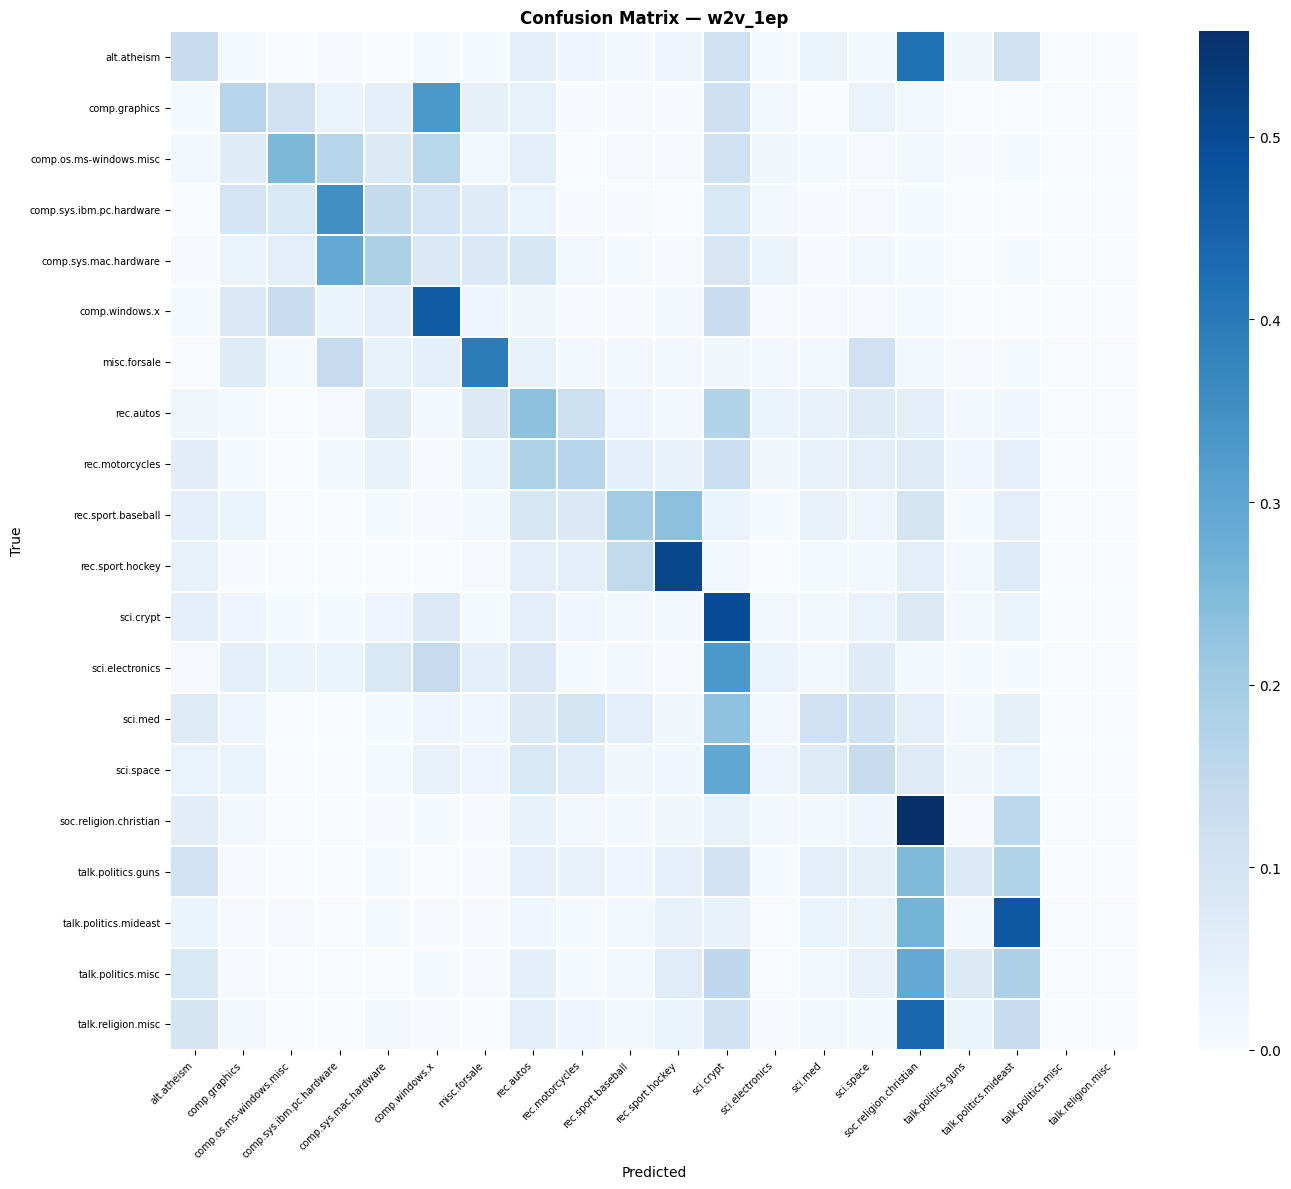

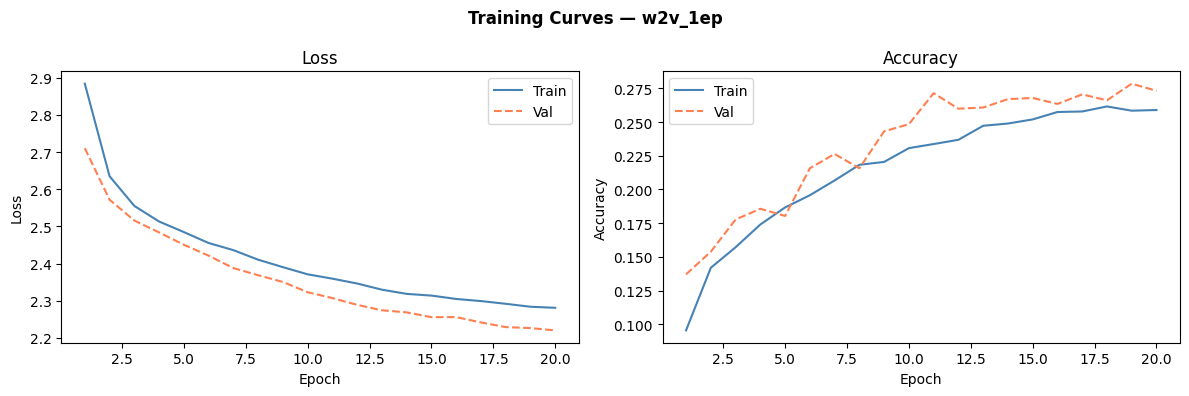

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▃▄▄▅▅▆▆▆▇▇▇▇▇██████
train/loss,█▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
val/acc,▁▂▃▃▃▅▅▅▆▇█▇▇▇▇▇█▇██
val/loss,█▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁
best_val_acc,0.27851
epoch,20
test_accuracy,0.25664
train/acc,0.25896
train/loss,2.28116
val/acc,0.27321



W2V (1ep) Test Accuracy: 0.2566


In [8]:
# ── Hyperparameters (logged to W&B config) ─────────────────────────
CONFIG_W2V_1EP = {
    # Word2Vec settings
    'w2v_vector_size': 100,
    'w2v_window':      5,
    'w2v_min_count':   2,
    'w2v_sg':          1,       # 1=Skip-gram, 0=CBOW
    'w2v_epochs':      1,       # KEY: only 1 epoch
    # Neural network settings
    'nn_hidden_dim':   256,
    'nn_epochs':       20,
    'batch_size':      64,
    'learning_rate':   1e-3,
    'dropout_p':       0.3,
    'num_classes':     20,
    # Metadata
    'embedding_type':  'word2vec',
    'input_dim':       100,
}

# ── Train Word2Vec for 1 epoch ──────────────────────────────────────
print('Training Word2Vec (1 epoch)...')
w2v_1ep = Word2Vec(
    sentences=train_tokens,
    vector_size=CONFIG_W2V_1EP['w2v_vector_size'],
    window=CONFIG_W2V_1EP['w2v_window'],
    min_count=CONFIG_W2V_1EP['w2v_min_count'],
    sg=CONFIG_W2V_1EP['w2v_sg'],
    epochs=CONFIG_W2V_1EP['w2v_epochs'],
    workers=4,
    seed=RANDOM_SEED
)
print(f'Vocabulary: {len(w2v_1ep.wv):,} words')

# ── Mean-pool word vectors → document embeddings ────────────────────
def get_doc_embeddings(w2v_model, corpus_tokens, vector_size):
    """Average word vectors per document (mean pooling)."""
    embeddings = []
    for tokens in corpus_tokens:
        vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
        embeddings.append(
            np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)
        )
    return np.array(embeddings, dtype=np.float32)

V = CONFIG_W2V_1EP['w2v_vector_size']
X_train_1ep = get_doc_embeddings(w2v_1ep, train_tokens, V)
X_test_1ep  = get_doc_embeddings(w2v_1ep, test_tokens,  V)
print(f'Embedding matrix: {X_train_1ep.shape}')

# ── DataLoaders ─────────────────────────────────────────────────────
train_loader_1ep, val_loader_1ep, test_loader_1ep = build_dataloaders(
    X_train_1ep, y_train, X_test_1ep, y_test,
    batch_size=CONFIG_W2V_1EP['batch_size']
)

# ── Train neural network WITH W&B logging ───────────────────────────
print('\nTraining NN (this run will appear on W&B dashboard)...')
model_1ep = FeedforwardNN(
    input_dim=V,
    hidden_dim=CONFIG_W2V_1EP['nn_hidden_dim'],
    num_classes=NUM_CLASSES
)

history_1ep, results_1ep = train_and_evaluate_wandb(
    model=model_1ep,
    train_loader=train_loader_1ep,
    val_loader=val_loader_1ep,
    test_loader=test_loader_1ep,
    config=CONFIG_W2V_1EP,
    run_name='w2v_1ep',
    tags=['word2vec', 'task1b', 'baseline']
)

print(f'\nW2V (1ep) Test Accuracy: {results_1ep["accuracy"]:.4f}')

---
## Cell 9 — Task 1b: Word2Vec with 15 Epochs (Full Training)

Training Word2Vec (15 epochs)...
Vocabulary: 36,229 words

Training NN with 15-epoch Word2Vec embeddings...


Epoch [01/20] | Train Loss: 2.4155 Acc: 0.3490 | Val Loss: 1.8380 Acc: 0.4792
Epoch [02/20] | Train Loss: 1.6315 Acc: 0.5112 | Val Loss: 1.4737 Acc: 0.5402
Epoch [03/20] | Train Loss: 1.4185 Acc: 0.5621 | Val Loss: 1.3368 Acc: 0.6021
Epoch [04/20] | Train Loss: 1.3236 Acc: 0.5939 | Val Loss: 1.2720 Acc: 0.6216
Epoch [05/20] | Train Loss: 1.2639 Acc: 0.6081 | Val Loss: 1.2387 Acc: 0.6269
Epoch [06/20] | Train Loss: 1.2229 Acc: 0.6225 | Val Loss: 1.2062 Acc: 0.6384
Epoch [07/20] | Train Loss: 1.1870 Acc: 0.6388 | Val Loss: 1.1916 Acc: 0.6375
Epoch [08/20] | Train Loss: 1.1606 Acc: 0.6423 | Val Loss: 1.1834 Acc: 0.6375
Epoch [09/20] | Train Loss: 1.1372 Acc: 0.6536 | Val Loss: 1.1624 Acc: 0.6410
Epoch [10/20] | Train Loss: 1.1201 Acc: 0.6526 | Val Loss: 1.1637 Acc: 0.6499
Epoch [11/20] | Train Loss: 1.1065 Acc: 0.6625 | Val Loss: 1.1596 Acc: 0.6401
Epoch [12/20] | Train Loss: 1.0915 Acc: 0.6638 | Val Loss: 1.1466 Acc: 0.6543
Epoch [13/20] | Train Loss: 1.0826 Acc: 0.6676 | Val Loss: 1.146

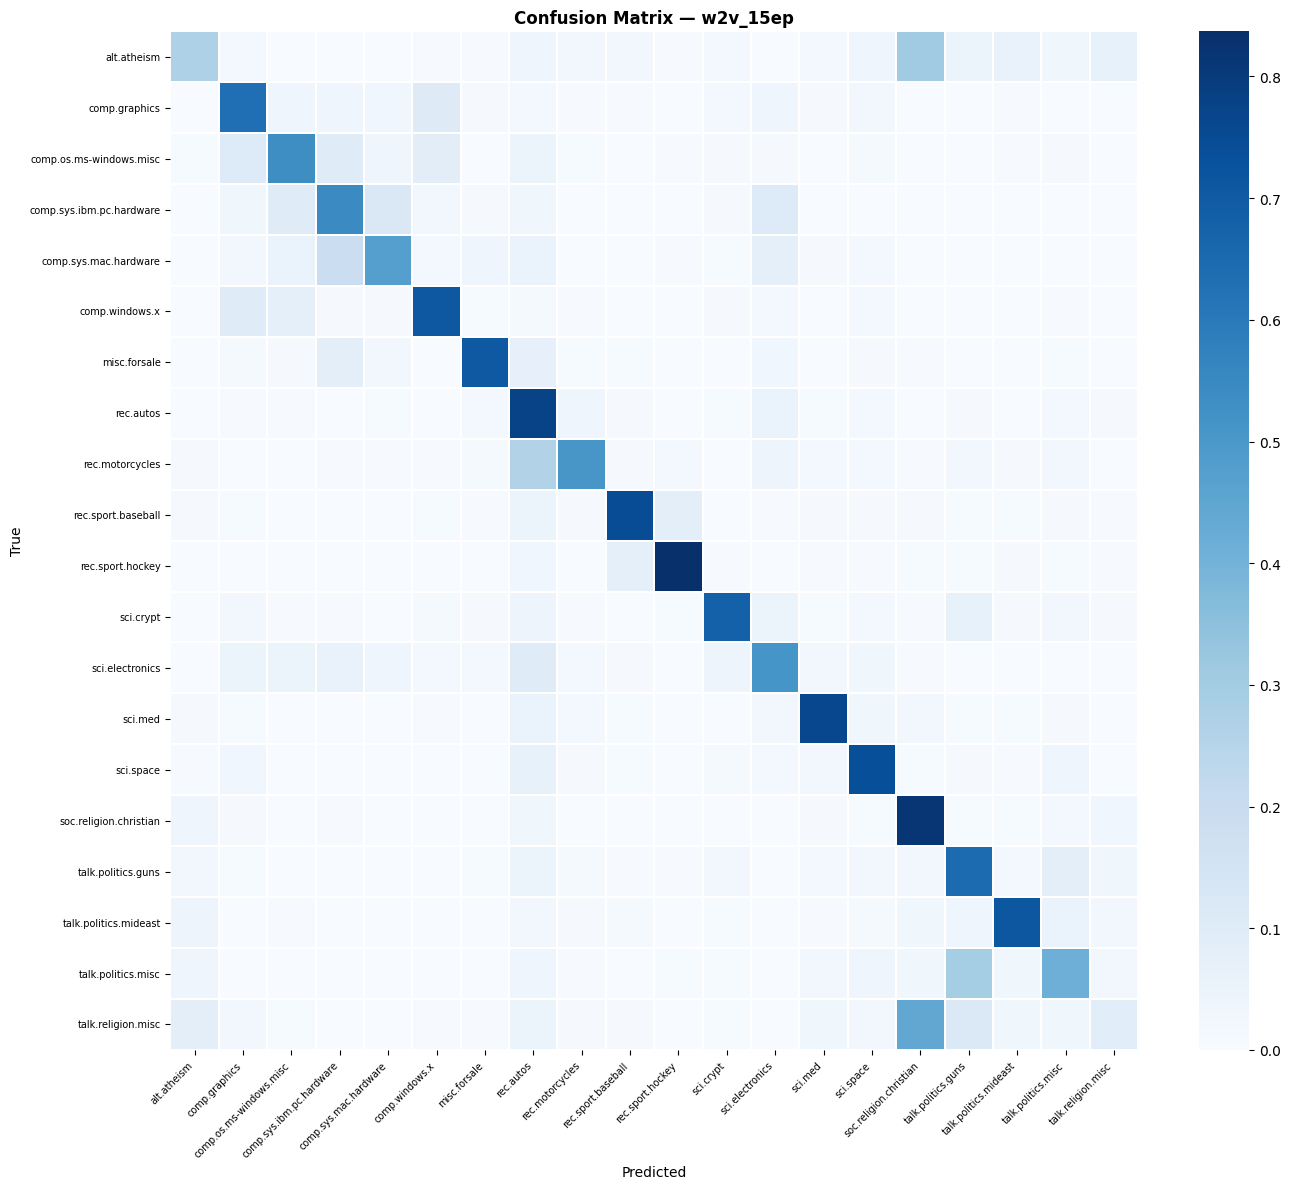

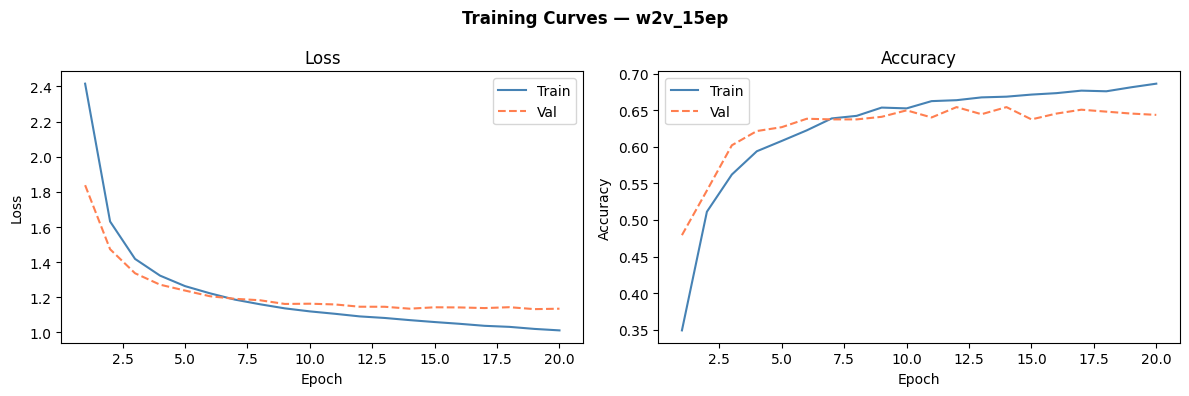

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▄▅▆▆▇▇▇▇▇██████████
train/loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▆▇▇▇▇▇▇█▇███▇█████
val/loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.65429
epoch,20
test_accuracy,0.62095
train/acc,0.68634
train/loss,1.01194
val/acc,0.64368



W2V (1ep)  Test Accuracy: 0.2566
W2V (15ep) Test Accuracy: 0.6210
Improvement: +0.3643


In [9]:
# Same config but w2v_epochs=15
CONFIG_W2V_15EP = {**CONFIG_W2V_1EP,
                   'w2v_epochs': 15}   # only this changes

# ── Train Word2Vec for 15 epochs ────────────────────────────────────
print('Training Word2Vec (15 epochs)...')
w2v_15ep = Word2Vec(
    sentences=train_tokens,
    vector_size=CONFIG_W2V_15EP['w2v_vector_size'],
    window=CONFIG_W2V_15EP['w2v_window'],
    min_count=CONFIG_W2V_15EP['w2v_min_count'],
    sg=CONFIG_W2V_15EP['w2v_sg'],
    epochs=CONFIG_W2V_15EP['w2v_epochs'],
    workers=4,
    seed=RANDOM_SEED
)
print(f'Vocabulary: {len(w2v_15ep.wv):,} words')

X_train_15ep = get_doc_embeddings(w2v_15ep, train_tokens, V)
X_test_15ep  = get_doc_embeddings(w2v_15ep, test_tokens,  V)

train_loader_15ep, val_loader_15ep, test_loader_15ep = build_dataloaders(
    X_train_15ep, y_train, X_test_15ep, y_test,
    batch_size=CONFIG_W2V_15EP['batch_size']
)

print('\nTraining NN with 15-epoch Word2Vec embeddings...')
model_15ep = FeedforwardNN(
    input_dim=V,
    hidden_dim=CONFIG_W2V_15EP['nn_hidden_dim'],
    num_classes=NUM_CLASSES
)

history_15ep, results_15ep = train_and_evaluate_wandb(
    model=model_15ep,
    train_loader=train_loader_15ep,
    val_loader=val_loader_15ep,
    test_loader=test_loader_15ep,
    config=CONFIG_W2V_15EP,
    run_name='w2v_15ep',
    tags=['word2vec', 'task1b', 'full_training']
)

print(f'\nW2V (1ep)  Test Accuracy: {results_1ep["accuracy"]:.4f}')
print(f'W2V (15ep) Test Accuracy: {results_15ep["accuracy"]:.4f}')
print(f'Improvement: {results_15ep["accuracy"] - results_1ep["accuracy"]:+.4f}')

---
## Cell 10 — Task 1b: Embedding Space Comparison Plots

t-SNE and PCA side-by-side for 1 epoch vs 15 epochs.  
Plots are saved locally **and** uploaded to W&B Media tab.

Running t-SNE (1-3 minutes)...


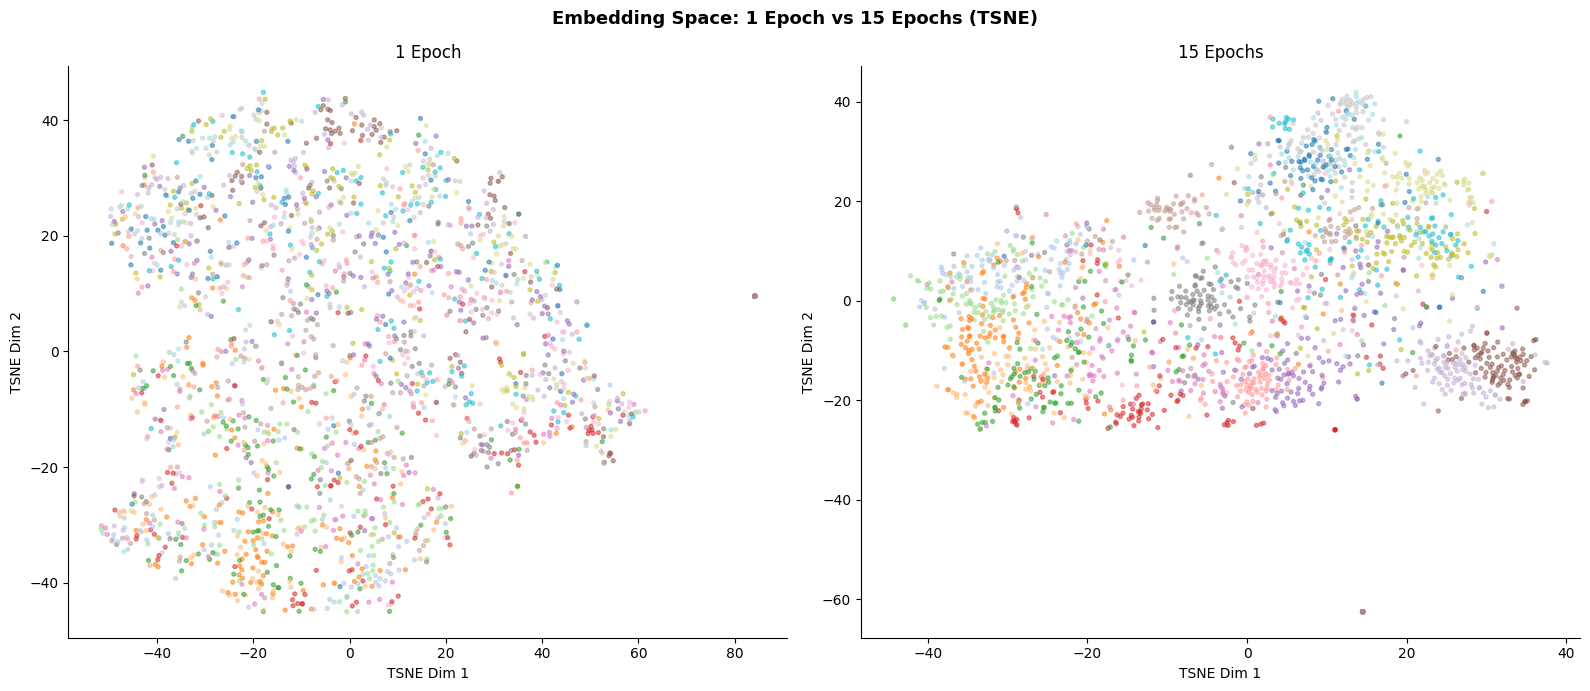

Running PCA...


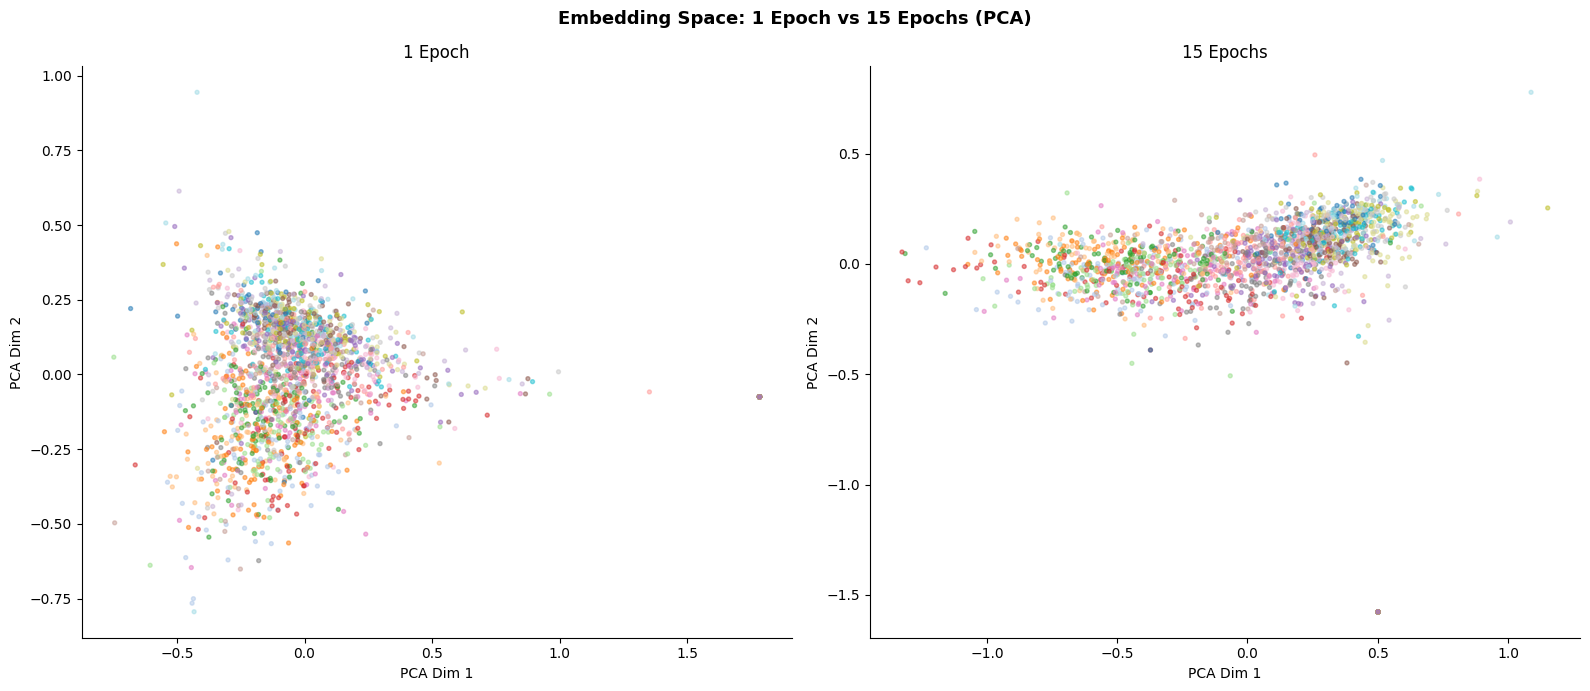

W2V 1ep: 25/25 probe words found


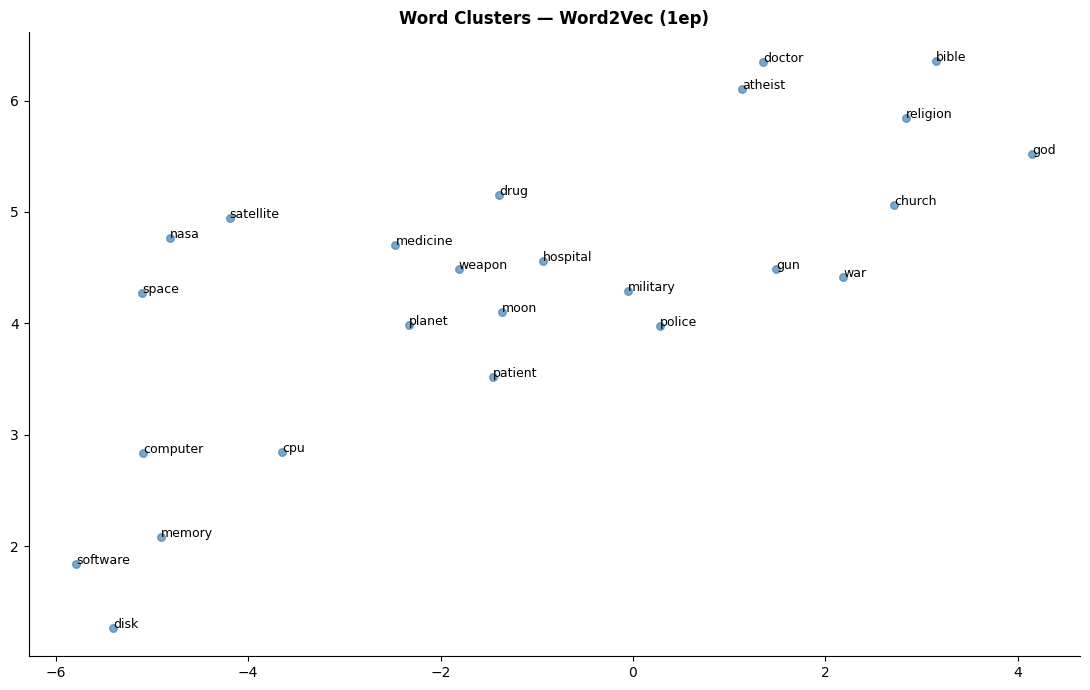

W2V 15ep: 25/25 probe words found


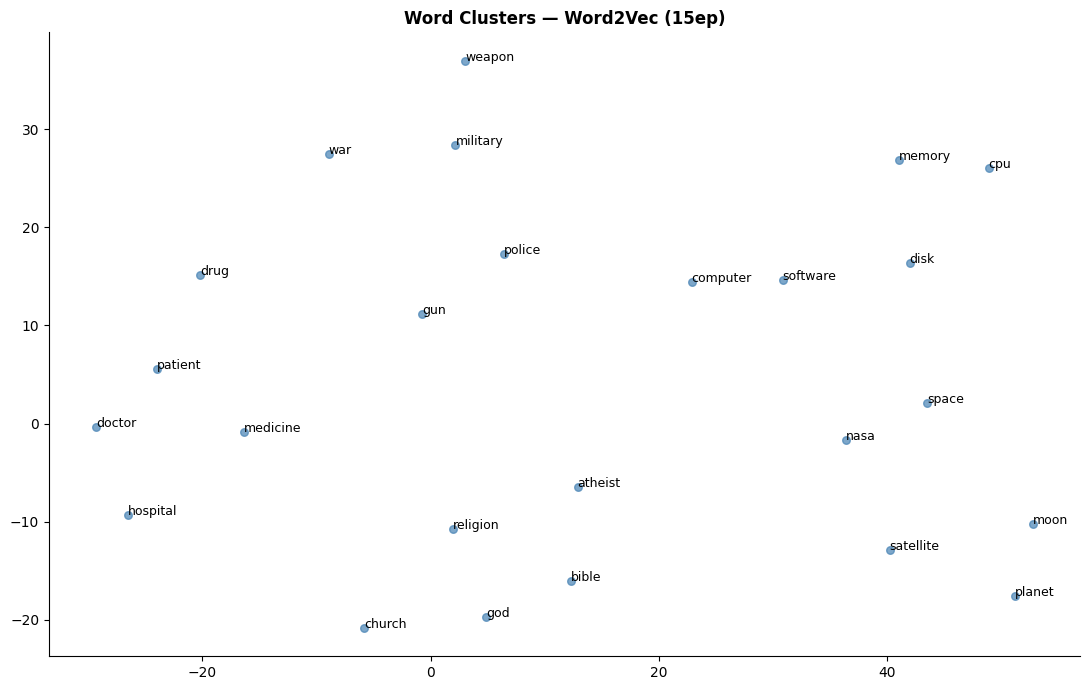

In [10]:
# Subsample for speed (t-SNE is O(n^2))
N_VIZ = 2000
idx   = np.random.choice(len(X_test_1ep), N_VIZ, replace=False)

# ── t-SNE comparison ────────────────────────────────────────────────
print('Running t-SNE (1-3 minutes)...')
plot_embedding_comparison(
    vecs_1ep=X_test_1ep[idx], vecs_nep=X_test_15ep[idx],
    labels_ids=y_test[idx],   n_epochs=15,
    method='tsne',            save_name='w2v_embedding_comparison',
    log_to_wandb=True
)

# ── PCA comparison ──────────────────────────────────────────────────
print('Running PCA...')
plot_embedding_comparison(
    vecs_1ep=X_test_1ep[idx], vecs_nep=X_test_15ep[idx],
    labels_ids=y_test[idx],   n_epochs=15,
    method='pca',             save_name='w2v_embedding_comparison',
    log_to_wandb=True
)

# ── Word cluster plots ───────────────────────────────────────────────
# These show whether semantically related words cluster together
PROBE_WORDS = [
    'god', 'religion', 'church', 'bible', 'atheist',
    'gun', 'weapon', 'military', 'war', 'police',
    'space', 'nasa', 'satellite', 'moon', 'planet',
    'computer', 'software', 'disk', 'memory', 'cpu',
    'doctor', 'medicine', 'patient', 'hospital', 'drug',
]

# Log word clusters inside a shared W&B run
with wandb.init(project=WANDB_PROJECT, name='word_clusters', reinit=True):
    for ep_label, w2v_model in [('1ep', w2v_1ep), ('15ep', w2v_15ep)]:
        valid_words  = [w for w in PROBE_WORDS if w in w2v_model.wv]
        word_vectors = np.array([w2v_model.wv[w] for w in valid_words])
        print(f'W2V {ep_label}: {len(valid_words)}/{len(PROBE_WORDS)} probe words found')
        plot_word_clusters(
            word_vectors=word_vectors,
            words=valid_words,
            title=f'Word Clusters — Word2Vec ({ep_label})',
            save_name=f'w2v_{ep_label}_word_clusters',
            log_to_wandb=True,
            wandb_key=f'word_clusters_{ep_label}'
        )

---
## Cell 11 — Task 1c: TF-IDF + SVD (LSA)

TF-IDF scores word importance by frequency. SVD (LSA) compresses 20,000 dims → 100.  
Same neural network architecture — only the input representation changes.

Fitting TF-IDF + TruncatedSVD pipeline...
Vocabulary size   : 20,000
Embedding shape   : (11314, 100)

Training NN with TF-IDF embeddings...


Epoch [01/20] | Train Loss: 2.9157 Acc: 0.2546 | Val Loss: 2.7589 Acc: 0.4686
Epoch [02/20] | Train Loss: 2.4642 Acc: 0.5006 | Val Loss: 2.1216 Acc: 0.5721
Epoch [03/20] | Train Loss: 1.8849 Acc: 0.5656 | Val Loss: 1.6562 Acc: 0.6127
Epoch [04/20] | Train Loss: 1.5655 Acc: 0.6008 | Val Loss: 1.4378 Acc: 0.6375
Epoch [05/20] | Train Loss: 1.4140 Acc: 0.6154 | Val Loss: 1.3343 Acc: 0.6419
Epoch [06/20] | Train Loss: 1.3345 Acc: 0.6250 | Val Loss: 1.2763 Acc: 0.6437
Epoch [07/20] | Train Loss: 1.2790 Acc: 0.6294 | Val Loss: 1.2360 Acc: 0.6437
Epoch [08/20] | Train Loss: 1.2452 Acc: 0.6348 | Val Loss: 1.2143 Acc: 0.6472
Epoch [09/20] | Train Loss: 1.2196 Acc: 0.6420 | Val Loss: 1.1996 Acc: 0.6490
Epoch [10/20] | Train Loss: 1.1927 Acc: 0.6453 | Val Loss: 1.1917 Acc: 0.6428
Epoch [11/20] | Train Loss: 1.1813 Acc: 0.6510 | Val Loss: 1.1832 Acc: 0.6490
Epoch [12/20] | Train Loss: 1.1664 Acc: 0.6470 | Val Loss: 1.1753 Acc: 0.6499
Epoch [13/20] | Train Loss: 1.1564 Acc: 0.6492 | Val Loss: 1.165

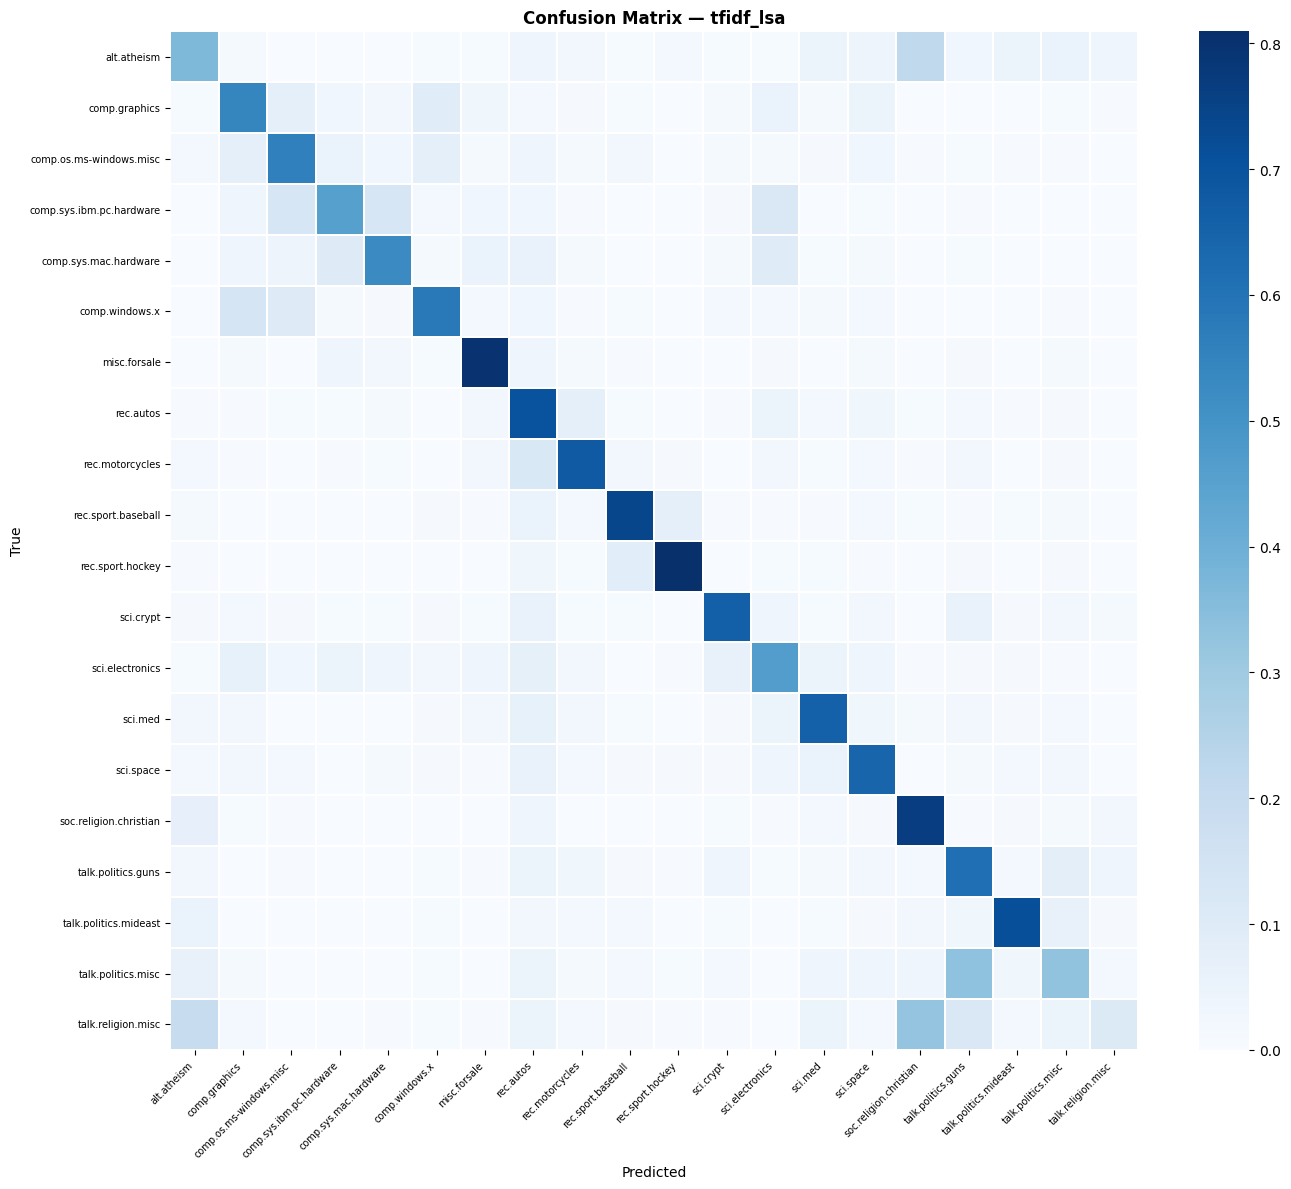

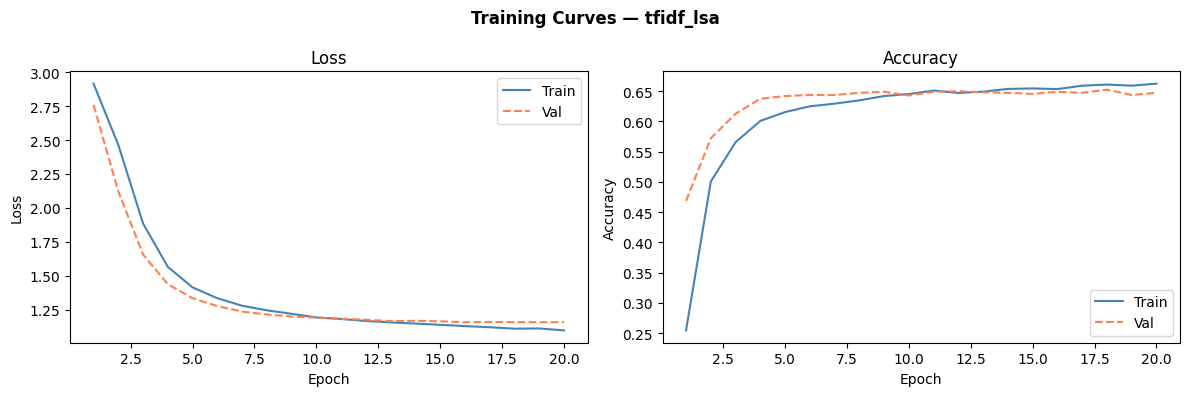

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▇▇▇▇█████████████
train/loss,█▆▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▅▆▇████████████████
val/loss,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.65252
epoch,20
test_accuracy,0.60011
train/acc,0.66238
train/loss,1.09734
val/acc,0.64721



TF-IDF Test Accuracy      : 0.6001
W2V (15ep) Test Accuracy  : 0.6210
Delta (TF-IDF - W2V)      : -0.0208


In [11]:
CONFIG_TFIDF = {
    'tfidf_max_features': 20000,
    'tfidf_n_components': 100,
    'tfidf_ngram_range':  '(1,2)',  # stored as string for W&B logging
    'tfidf_sublinear_tf': True,
    'nn_hidden_dim':      256,
    'nn_epochs':          20,
    'batch_size':         64,
    'learning_rate':      1e-3,
    'dropout_p':          0.3,
    'num_classes':        20,
    'embedding_type':     'tfidf_lsa',
    'input_dim':          100,
}

# ── Fit TF-IDF + SVD on training data ONLY ──────────────────────────
print('Fitting TF-IDF + TruncatedSVD pipeline...')
tfidf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=CONFIG_TFIDF['tfidf_max_features'],
        ngram_range=(1, 2),
        sublinear_tf=CONFIG_TFIDF['tfidf_sublinear_tf'],
    )),
    ('svd', TruncatedSVD(
        n_components=CONFIG_TFIDF['tfidf_n_components'],
        random_state=RANDOM_SEED
    ))
])

# fit_transform on TRAIN — transform (no refit) on TEST
X_train_tfidf = tfidf_pipeline.fit_transform(train_strings).astype(np.float32)
X_test_tfidf  = tfidf_pipeline.transform(test_strings).astype(np.float32)

vocab_size = len(tfidf_pipeline.named_steps['tfidf'].vocabulary_)
print(f'Vocabulary size   : {vocab_size:,}')
print(f'Embedding shape   : {X_train_tfidf.shape}')

# ── DataLoaders ─────────────────────────────────────────────────────
train_loader_tfidf, val_loader_tfidf, test_loader_tfidf = build_dataloaders(
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    batch_size=CONFIG_TFIDF['batch_size']
)

# ── Train neural network WITH W&B logging ───────────────────────────
print('\nTraining NN with TF-IDF embeddings...')
model_tfidf = FeedforwardNN(
    input_dim=CONFIG_TFIDF['tfidf_n_components'],
    hidden_dim=CONFIG_TFIDF['nn_hidden_dim'],
    num_classes=NUM_CLASSES
)

# Add vocab size to config before logging
CONFIG_TFIDF['tfidf_vocab_size'] = vocab_size

history_tfidf, results_tfidf = train_and_evaluate_wandb(
    model=model_tfidf,
    train_loader=train_loader_tfidf,
    val_loader=val_loader_tfidf,
    test_loader=test_loader_tfidf,
    config=CONFIG_TFIDF,
    run_name='tfidf_lsa',
    tags=['tfidf', 'lsa', 'task1c']
)

print(f'\nTF-IDF Test Accuracy      : {results_tfidf["accuracy"]:.4f}')
print(f'W2V (15ep) Test Accuracy  : {results_15ep["accuracy"]:.4f}')
print(f'Delta (TF-IDF - W2V)      : {results_tfidf["accuracy"] - results_15ep["accuracy"]:+.4f}')

---
## Cell 12 — Task 1d: Custom Experiment — Feature Concatenation

**Hypothesis:** Word2Vec captures semantic similarity; TF-IDF captures term importance.  
Concatenating both → 200-dim input that combines both signals.

Combined feature dim: 200
  Word2Vec (15ep): 100 dims (semantic meaning)
  TF-IDF + LSA   : 100 dims (term importance)

Training NN with concatenated features...


Epoch [01/20] | Train Loss: 2.3722 Acc: 0.3710 | Val Loss: 1.7444 Acc: 0.5146
Epoch [02/20] | Train Loss: 1.5375 Acc: 0.5538 | Val Loss: 1.3648 Acc: 0.6118
Epoch [03/20] | Train Loss: 1.3181 Acc: 0.6100 | Val Loss: 1.2421 Acc: 0.6375
Epoch [04/20] | Train Loss: 1.2188 Acc: 0.6352 | Val Loss: 1.1790 Acc: 0.6596
Epoch [05/20] | Train Loss: 1.1559 Acc: 0.6545 | Val Loss: 1.1441 Acc: 0.6543
Epoch [06/20] | Train Loss: 1.1140 Acc: 0.6617 | Val Loss: 1.1310 Acc: 0.6720
Epoch [07/20] | Train Loss: 1.0778 Acc: 0.6735 | Val Loss: 1.1020 Acc: 0.6614
Epoch [08/20] | Train Loss: 1.0475 Acc: 0.6791 | Val Loss: 1.0971 Acc: 0.6693
Epoch [09/20] | Train Loss: 1.0309 Acc: 0.6826 | Val Loss: 1.0885 Acc: 0.6658
Epoch [10/20] | Train Loss: 1.0156 Acc: 0.6893 | Val Loss: 1.0775 Acc: 0.6790
Epoch [11/20] | Train Loss: 0.9869 Acc: 0.6931 | Val Loss: 1.0703 Acc: 0.6746
Epoch [12/20] | Train Loss: 0.9770 Acc: 0.6970 | Val Loss: 1.0582 Acc: 0.6852
Epoch [13/20] | Train Loss: 0.9609 Acc: 0.7021 | Val Loss: 1.065

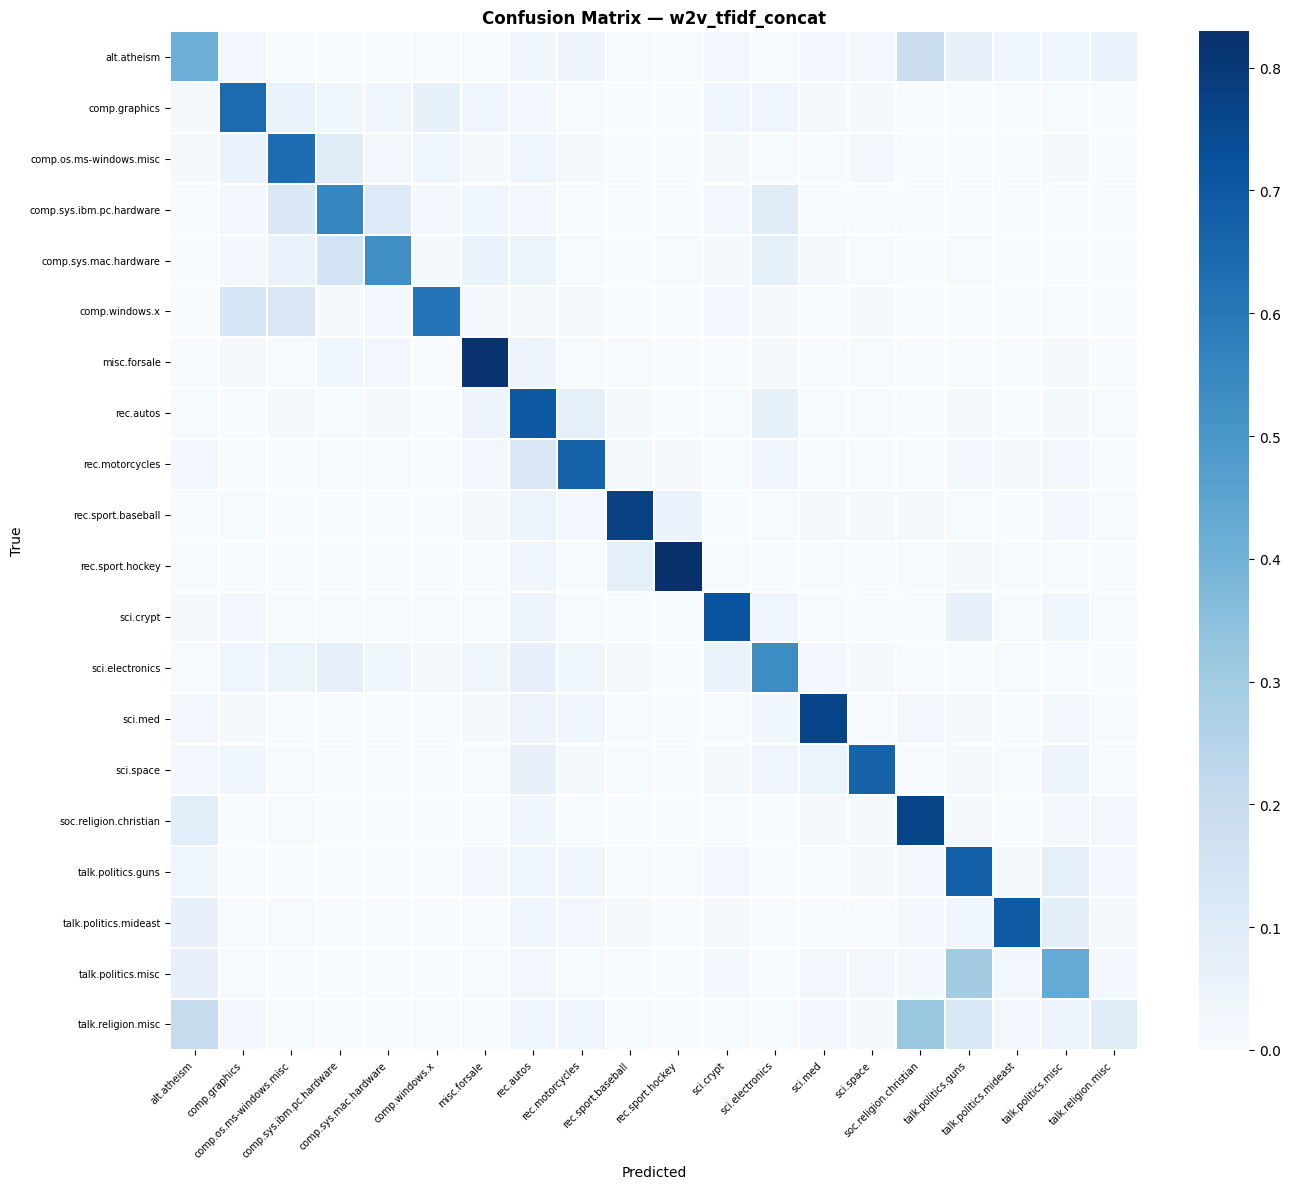

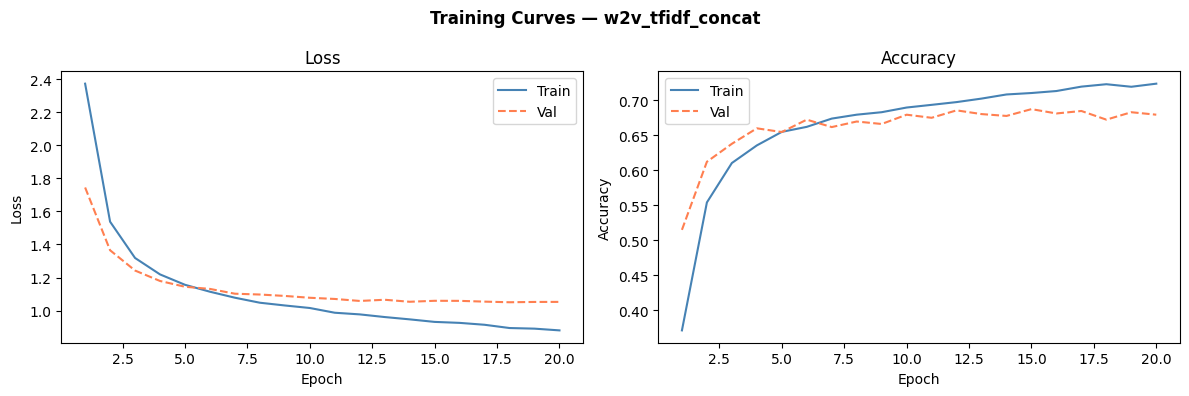

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▆▇▇▇▇▇▇▇▇████████
train/loss,█▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▅▆▇▇▇▇▇▇█▇██████▇██
val/loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.687
epoch,20
test_accuracy,0.6402
train/acc,0.72336
train/loss,0.88022
val/acc,0.67905



Combined Test Accuracy    : 0.6402
W2V (15ep) Test Accuracy  : 0.6210
TF-IDF Test Accuracy      : 0.6001


In [12]:
CONFIG_COMBINED = {
    'w2v_vector_size':    100,
    'tfidf_n_components': 100,
    'combined_input_dim': 200,    # 100 + 100
    'nn_hidden_dim':      256,
    'nn_epochs':          20,
    'batch_size':         64,
    'learning_rate':      1e-3,
    'dropout_p':          0.3,
    'num_classes':        20,
    'embedding_type':     'w2v_tfidf_concat',
    'input_dim':          200,
}

# ── Concatenate W2V(15ep) + TF-IDF vectors ──────────────────────────
# hstack joins columns: (N, 100) + (N, 100) → (N, 200)
X_train_comb = np.hstack([X_train_15ep, X_train_tfidf])
X_test_comb  = np.hstack([X_test_15ep,  X_test_tfidf])

COMBINED_DIM = X_train_comb.shape[1]   # = 200
print(f'Combined feature dim: {COMBINED_DIM}')
print(f'  Word2Vec (15ep): 100 dims (semantic meaning)')
print(f'  TF-IDF + LSA   : 100 dims (term importance)')

# ── DataLoaders ─────────────────────────────────────────────────────
train_loader_comb, val_loader_comb, test_loader_comb = build_dataloaders(
    X_train_comb, y_train, X_test_comb, y_test,
    batch_size=CONFIG_COMBINED['batch_size']
)

# ── Train neural network WITH W&B logging ───────────────────────────
print('\nTraining NN with concatenated features...')
model_comb = FeedforwardNN(
    input_dim=COMBINED_DIM,     # 200 — only change from previous experiments
    hidden_dim=CONFIG_COMBINED['nn_hidden_dim'],
    num_classes=NUM_CLASSES
)

history_comb, results_comb = train_and_evaluate_wandb(
    model=model_comb,
    train_loader=train_loader_comb,
    val_loader=val_loader_comb,
    test_loader=test_loader_comb,
    config=CONFIG_COMBINED,
    run_name='w2v_tfidf_concat',
    tags=['combined', 'task1d', 'custom']
)

print(f'\nCombined Test Accuracy    : {results_comb["accuracy"]:.4f}')
print(f'W2V (15ep) Test Accuracy  : {results_15ep["accuracy"]:.4f}')
print(f'TF-IDF Test Accuracy      : {results_tfidf["accuracy"]:.4f}')

---
## Cell 13 — Final Summary: All Experiments

Prints a comparison table and logs the final bar chart to W&B.

Experiment                       Test Accuracy
Word2Vec (1 epoch)                      0.2566
Word2Vec (15 epochs)                    0.6210
TF-IDF + LSA                            0.6001
W2V + TF-IDF (concat)                   0.6402 ← BEST


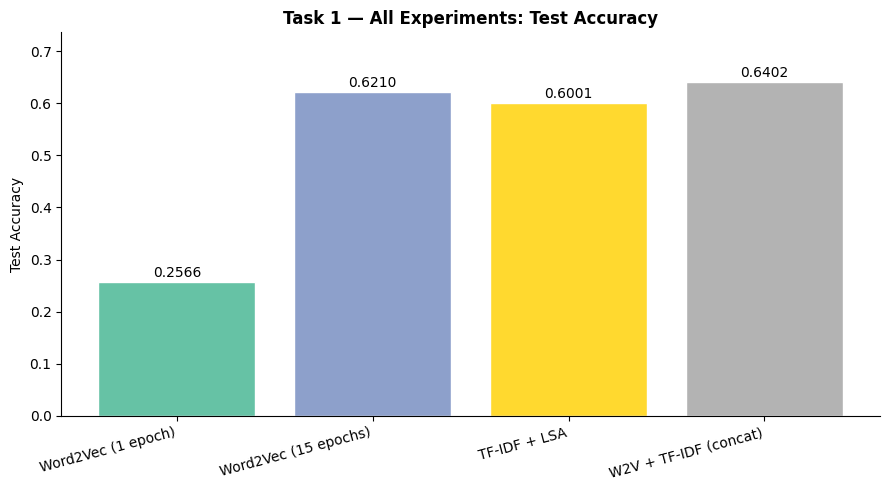


All plots saved to: outputs/
All runs visible at: https://wandb.ai/<your-username>/nalapro-task1

Files saved:
  outputs/task1_final_comparison.png
  outputs/tfidf_lsa_confusion_matrix.png
  outputs/tfidf_lsa_model.pt
  outputs/tfidf_lsa_training_curves.png
  outputs/w2v_15ep_confusion_matrix.png
  outputs/w2v_15ep_model.pt
  outputs/w2v_15ep_training_curves.png
  outputs/w2v_15ep_word_clusters.png
  outputs/w2v_1ep_confusion_matrix.png
  outputs/w2v_1ep_model.pt
  outputs/w2v_1ep_training_curves.png
  outputs/w2v_1ep_word_clusters.png
  outputs/w2v_embedding_comparison_pca.png
  outputs/w2v_embedding_comparison_tsne.png
  outputs/w2v_tfidf_concat_confusion_matrix.png
  outputs/w2v_tfidf_concat_model.pt
  outputs/w2v_tfidf_concat_training_curves.png


In [13]:
# ── Accuracy table ──────────────────────────────────────────────────
all_results = {
    'Word2Vec (1 epoch)':    results_1ep['accuracy'],
    'Word2Vec (15 epochs)':  results_15ep['accuracy'],
    'TF-IDF + LSA':          results_tfidf['accuracy'],
    'W2V + TF-IDF (concat)': results_comb['accuracy'],
}

print('=' * 55)
print(f'{"Experiment":<30} {"Test Accuracy":>15}')
print('=' * 55)
for name, acc in all_results.items():
    marker = ' ← BEST' if acc == max(all_results.values()) else ''
    print(f'{name:<30} {acc:>15.4f}{marker}')
print('=' * 55)

# ── Bar chart (logged to W&B) ────────────────────────────────────────
plot_bar_comparison(
    results_dict=all_results,
    title='Task 1 — All Experiments: Test Accuracy',
    save_name='task1_final_comparison',
    log_to_wandb=True
)

print(f'\nAll plots saved to: outputs/')
print(f'All runs visible at: https://wandb.ai/<your-username>/{WANDB_PROJECT}')
print('\nFiles saved:')
for f in sorted(os.listdir('outputs')):
    print(f'  outputs/{f}')

---
## What you will see on the W&B Dashboard

Go to **https://wandb.ai** → your project **nalapro-task1**

### Runs Table
All 4 experiments side-by-side with their configs and final test accuracy.

### For each run (click any run name):
| Tab | What's there |
|-----|--------------|
| **Charts** | Live train/val loss and accuracy curves per epoch |
| **Media** | Confusion matrix heatmap, training curves image |
| **Config** | All hyperparameters (vector_size, epochs, lr, etc.) |
| **Summary** | Final test_accuracy and best_val_acc |
| **Artifacts** | Trained model weights (.pt file) |
| **Gradients** | Weight and gradient histograms (from wandb.watch) |

### Parallel Coordinates Plot
In the Runs Table → click **Add visualization** → **Parallel Coordinates**  
Shows how hyperparameters relate to test accuracy across all runs.

### Comparing runs
Tick two or more runs → **Compare** button → overlaid charts side by side.

### Embedding comparison + word clusters
In the **embedding_comparison** and **word_clusters** runs → Media tab → see all plots.